In [ ]:
import numpy as np
import torch
from torch.utils.data import DataLoader, Dataset, random_split
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import cross_validate
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch
import matplotlib.pyplot as plt
import torch.optim as optim
from torch import nn
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


In [2]:
features_0 = np.array(np.load("data/ModEsq00.pkl", allow_pickle=True))
features_1 = np.array(np.load("data/ModEsq01.pkl", allow_pickle=True))
features_2 = np.array(np.load("data/ModEsq02.pkl", allow_pickle=True))
features_3 = np.array(np.load("data/ModEsq03.pkl", allow_pickle=True))
features_4 = np.array(np.load("data/ModEsq04.pkl", allow_pickle=True))
features_5 = np.array(np.load("data/ModEsq05.pkl", allow_pickle=True))
features_6 = np.array(np.load("data/ModEsq06.pkl", allow_pickle=True))
features_7 = np.array(np.load("data/ModEsq07.pkl", allow_pickle=True))

all_features = np.concatenate([features_0, features_1, features_2, features_3, 
                               features_4, features_5, features_6, features_7], axis=0)

old_label_arr = np.array([np.tile(i,3000) for i in np.arange(0,8)]).flatten()

In [3]:
# Reverse the class_to_poles dictionary


# Define the mapping from class labels (0 to 7) to the new 3-element array format
# where each element in the array represents the number of poles on [bt], [bb], and [tb]
class_to_poles = {
    0: [1, 0, 0],  # 1 pole on [bt]
    1: [0, 1, 0],  # 1 pole on [bb]
    2: [0, 0, 1],  # 1 pole on [tb]
    3: [1, 1, 0],  # 1 pole on [bt] and 1 pole on [bb]
    4: [0, 1, 1],  # 1 pole on [bb] and 1 pole on [tb]
    5: [1, 1, 1],  # 1 pole on each of [bt], [bb], and [tb]
    6: [0, 2, 1],  # 2 poles on [bb] and 1 pole on [tb]
    7: [0, 1, 2]   # 1 pole on [bb] and 2 poles on [tb]
}

def convert_labels(old_labels):
    # Initialize a new array with shape (length of old labels, 3)
    new_labels = np.zeros((len(old_labels), 3), dtype=int)
    
    # Populate the new label array based on the mapping
    for i, label in enumerate(old_labels):
        new_labels[i] = class_to_poles[label]
    
    return new_labels

# Example usage:

new_label_arr = convert_labels(old_label_arr)

print("Old Labels:\n", old_label_arr)
print("New Labels:\n", new_label_arr)

Old Labels:
 [0 0 0 ... 7 7 7]
New Labels:
 [[1 0 0]
 [1 0 0]
 [1 0 0]
 ...
 [0 1 2]
 [0 1 2]
 [0 1 2]]


In [11]:
scaler = StandardScaler()
features_scaled = scaler.fit_transform(all_features)

X_train, X_test, y_train_reg, y_test_reg = train_test_split(features_scaled, new_label_arr)
_, _, y_train_cl, y_test_cl = train_test_split(features_scaled, old_label_arr)

# Option 1: RNN regression

In [42]:
class PoleDataset(Dataset):
    def __init__(self, features, targets):
        self.features = torch.tensor(features, dtype=torch.float32)
        self.targets = torch.tensor(targets, dtype=torch.float32)
        
    def __len__(self):
        return len(self.features)
    
    def __getitem__(self, idx):
        return self.features[idx], self.targets[idx]


# Create Dataset objects
train_dataset = PoleDataset(X_train, y_train_reg)
test_dataset = PoleDataset(X_test, y_test_reg)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)


In [43]:
# Define the neural network model
# class PoleRegression(nn.Module):
#     def __init__(self, input_size=100, hidden_size=100):
#         super(PoleRegression, self).__init__()
#         # Define layers
#         self.fc1 = nn.Linear(input_size, hidden_size)
#         self.fc2 = nn.Linear(hidden_size, hidden_size)
#         self.output = nn.Linear(hidden_size, 3)  # Output size of 3 for regression targets

#     def forward(self, x):
#         x = F.relu(self.fc1(x))
#         x = F.relu(self.fc2(x))
#         return self.output(x)

class PoleRegression(nn.Module):
    def __init__(self, input_size=1, hidden_size=100, output_size=3):
        super(PoleRegression, self).__init__()
        self.hidden_size = hidden_size

        # Define layers
        self.gru = nn.GRU(input_size, hidden_size, batch_first=True)
        self.fc1 = nn.Linear(hidden_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.output = nn.Linear(hidden_size, output_size)  # Output size of 3 for regression targets

    def forward(self, x):
        # Reshape x to (batch_size, seq_length, input_size)
        x = x.unsqueeze(-1)  # Shape becomes (batch_size, 100, 1)
        # print(x.shape)
        # Pass through the GRU layer
        gru_out, _ = self.gru(x)  # Output shape: (batch_size, seq_length, hidden_size)
        
        # Take the output from the last time step
        x = gru_out[:, -1, :]  # Shape: (batch_size, hidden_size)
        
        # Pass through fully connected layers
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        
        return self.output(x)

# Initialize model, loss function, and optimizer
model = PoleRegression()
criterion = nn.MSELoss()  # MSE Loss for regression
optimizer = optim.Adam(model.parameters(), lr=0.0001)

num_epochs = 1000
train_losses = []
test_losses = []

patience = 10  # Number of epochs to wait for improvement
min_delta = 1e-4  # Minimum change to qualify as an improvement
best_test_loss = float('inf')  # Initialize best test loss as infinity
patience_counter = 0  # Counter to track epochs without improvement

# Training loop with early stopping
for epoch in range(num_epochs):
    # Train phase
    model.train()
    train_loss = 0.0
    for inputs, targets in train_loader:
        optimizer.zero_grad()  # Reset gradients
        outputs = model(inputs)  # Get model predictions
        loss = criterion(outputs, targets)  # Calculate MSE loss
        loss.backward()  # Backpropagate the loss
        optimizer.step()  # Update the model weights
        
        train_loss += loss.item()  # Accumulate loss for tracking
    
    # Average training loss for this epoch
    train_loss /= len(train_loader)
    train_losses.append(train_loss)
    
    # Test phase (evaluate model on validation/test data)
    model.eval()
    test_loss = 0.0
    with torch.no_grad():  # No need to track gradients for evaluation
        for inputs, targets in test_loader:
            outputs = model(inputs)  # Get model predictions
            loss = criterion(outputs, targets)  # Calculate MSE loss
            test_loss += loss.item()  # Accumulate loss for tracking
    
    # Average test loss for this epoch
    test_loss /= len(test_loader)
    test_losses.append(test_loss)
    
    # Print epoch stats every 10 epochs
    if epoch % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_loss:.4f}, Test Loss: {test_loss:.4f}')
    
    # Early stopping check
    if test_loss < best_test_loss - min_delta:
        best_test_loss = test_loss
        patience_counter = 0  # Reset counter if test loss improves
    else:
        patience_counter += 1  # Increment counter if no improvement
    
    if patience_counter >= patience:
        print(f"Early stopping at epoch {epoch+1} with best test loss: {best_test_loss:.4f}")
        break


Epoch [1/1000], Train Loss: 0.8012, Test Loss: 0.7105
Epoch [11/1000], Train Loss: 0.3406, Test Loss: 0.3428
Epoch [21/1000], Train Loss: 0.3175, Test Loss: 0.3118
Epoch [31/1000], Train Loss: 0.2904, Test Loss: 0.2876


KeyboardInterrupt: 

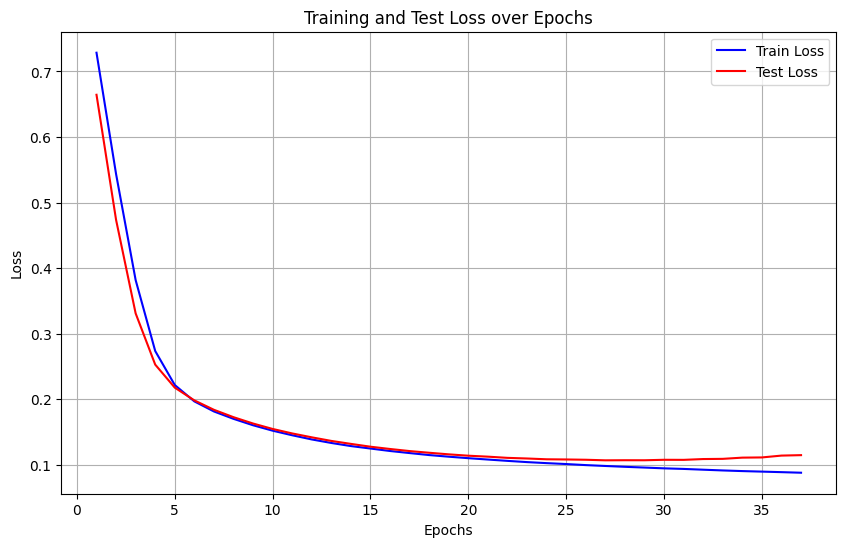

In [ ]:
# Plot train and test loss
plt.figure(figsize=(10, 6))
plt.plot(range(1, epoch +2), train_losses, label='Train Loss', color='blue')
plt.plot(range(1, epoch +2), test_losses, label='Test Loss', color='red')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Test Loss over Epochs')
plt.legend()
plt.grid(True)

# plt.yscale("log")
# plt.ylim(0,0.5)
plt.show()

In [44]:
model.eval()

acc_arr = []
with torch.no_grad():  # No need to track gradients for evaluation
    for inputs, targets in test_loader:
        outputs = model(inputs)  # Get model predictions
        acc_arr.append(torch.sum(torch.sum(np.round(outputs) == targets,axis=1) == 3)/targets.shape[0])
np.mean(acc_arr)

np.float32(0.21372767)

# Option 2: Classification

In [12]:
# Create Dataset objects
train_dataset = PoleDataset(X_train, y_train_cl)
test_dataset = PoleDataset(X_test, y_test_cl)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [15]:
targets.long()

tensor([5, 6, 5, 7, 1, 0, 5, 6, 7, 5, 7, 4, 5, 3, 2, 5, 0, 1, 2, 3, 6, 0, 6, 4,
        6, 3, 0, 4, 7, 3, 4, 1, 7, 7, 3, 1, 1, 6, 2, 7, 7, 5, 4, 6, 0, 2, 1, 5,
        1, 4, 4, 4, 4, 4, 3, 6, 3, 6, 6, 3, 5, 6, 5, 1])

In [20]:
# Define the neural network model
class PoleClassification(nn.Module):
    def __init__(self, input_size=100, hidden_size=100):
        super(PoleClassification, self).__init__()
        # Define layers
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.output = nn.Linear(hidden_size, 8)  # Output size of 8 for 8 classes

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.output(x)
        return F.softmax(x, dim=1)  # Softmax activation for multiclass classification

# Initialize model, loss function, and optimizer
model = PoleClassification()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.00001)

num_epochs = 1000
train_losses = []
test_losses = []

patience = 20  # Number of epochs to wait for improvement
min_delta = 1e-4  # Minimum change to qualify as an improvement
best_test_loss = float('inf')  # Initialize best test loss as infinity
patience_counter = 0  # Counter to track epochs without improvement

# Training loop with early stopping
for epoch in range(num_epochs):
    # Train phase
    model.train()
    train_loss = 0.0
    for inputs, targets in train_loader:
        optimizer.zero_grad()  # Reset gradients
        outputs = model(inputs)  # Get model predictions
        loss = criterion(outputs, targets.long())  # Calculate MSE loss
        loss.backward()  # Backpropagate the loss
        optimizer.step()  # Update the model weights
        
        train_loss += loss.item()  # Accumulate loss for tracking
    
    # Average training loss for this epoch
    train_loss /= len(train_loader)
    train_losses.append(train_loss)
    
    # Test phase (evaluate model on validation/test data)
    model.eval()
    test_loss = 0.0
    with torch.no_grad():  # No need to track gradients for evaluation
        for inputs, targets in test_loader:
            outputs = model(inputs)  # Get model predictions
            loss = criterion(outputs, targets.long())  # Calculate MSE loss
            test_loss += loss.item()  # Accumulate loss for tracking
    
    # Average test loss for this epoch
    test_loss /= len(test_loader)
    test_losses.append(test_loss)
    
    # Print epoch stats every 10 epochs
    if epoch % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_loss:.4f}, Test Loss: {test_loss:.4f}')
    
    # Early stopping check
    if test_loss < best_test_loss - min_delta:
        best_test_loss = test_loss
        patience_counter = 0  # Reset counter if test loss improves
    else:
        patience_counter += 1  # Increment counter if no improvement
    
    if patience_counter >= patience:
        print(f"Early stopping at epoch {epoch+1} with best test loss: {best_test_loss:.4f}")
        break


Epoch [1/1000], Train Loss: 2.0795, Test Loss: 2.0798
Epoch [11/1000], Train Loss: 2.0791, Test Loss: 2.0798
Epoch [21/1000], Train Loss: 2.0787, Test Loss: 2.0798
Early stopping at epoch 21 with best test loss: 2.0798


In [ ]:
model.eval()
acc_arr = []
with torch.no_grad():  # No need to track gradients for evaluation
    for inputs, targets in test_loader:
        outputs = np.argmax(model(inputs).detach().numpy(),axis=1)   
        acc_arr.append(accuracy_score(outputs,targets))
np.mean(acc_arr)

np.float64(0.13214760638297873)